In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data/processed_AIS_dataset.csv


# AIS Ship Anomaly Detection

**Data loading and Preprocessing**

In [2]:
import os
import glob
import pandas as pd
import numpy as np
import torch

from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader

DATA_DIR = "/kaggle/input/datasets/satyamrajput7913/ais-ship-tracking-vessel-dynamics-and-eta-data"
SEED = 42
sequence_length = 20
batch_size = 64
features = ["lat", "lon", "sog", "cog", "heading", "time_gap_minutes"]
feature_dim = len(features)

csv_files = glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True)
if not csv_files:
    raise FileNotFoundError(f"No CSV files found under {DATA_DIR}")

main_csv = max(csv_files, key=os.path.getsize)
df = pd.read_csv(main_csv, low_memory=False)

print(df.shape)
print(df.columns.tolist())


def normalize_column_name(name):
    return "".join(character for character in str(name).lower() if character.isalnum())


normalized_columns = {}
for column in df.columns:
    normalized_columns.setdefault(normalize_column_name(column), []).append(column)


def detect_column(aliases):
    for alias in aliases:
        key = normalize_column_name(alias)
        if key in normalized_columns:
            return normalized_columns[key][0]
    raise KeyError(f"Could not find any column matching: {aliases}")


selected_columns = {
    "mmsi": detect_column(["MMSI"]),
    "timestamp": detect_column(["BaseDateTime", "timestamp", "time"]),
    "lat": detect_column(["LAT", "Latitude", "lat"]),
    "lon": detect_column(["LON", "Longitude", "lon"]),
    "sog": detect_column(["SOG", "speed"]),
    "cog": detect_column(["COG", "course"]),
    "heading": detect_column(["Heading", "heading"]),
}

df = df[list(selected_columns.values())].rename(
    columns={source: target for target, source in selected_columns.items()}
)

df = df.dropna(
    subset=["mmsi", "timestamp", "lat", "lon", "sog", "cog", "heading"]
).copy()

df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)

for column in ["lat", "lon", "sog", "cog", "heading"]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = df.dropna(
    subset=["mmsi", "timestamp", "lat", "lon", "sog", "cog", "heading"]
).copy()

df = df[
    df["lat"].between(-90, 90, inclusive="both")
    & df["lon"].between(-180, 180, inclusive="both")
    & df["sog"].between(0, 80, inclusive="both")
    & df["cog"].between(0, 360, inclusive="both")
    & df["heading"].between(0, 360, inclusive="both")
].copy()

df["mmsi"] = df["mmsi"].astype(str)
df = df.sort_values(["mmsi", "timestamp"]).reset_index(drop=True)

df["time_gap_minutes"] = (
    df.groupby("mmsi", sort=False)["timestamp"]
    .diff()
    .dt.total_seconds()
    .div(60.0)
)

valid_gap = (
    np.isfinite(df["time_gap_minutes"])
    & (df["time_gap_minutes"] >= 0)
)
df["time_gap_minutes"] = df["time_gap_minutes"].where(valid_gap, 0.0)
df["time_gap_minutes"] = df["time_gap_minutes"].clip(0, 240)

ship_counts = df.groupby("mmsi").size()
eligible_ships = ship_counts[ship_counts > sequence_length].index.to_numpy()

if len(eligible_ships) < 3:
    raise ValueError("At least three ships with sufficient observations are required.")

rng = np.random.default_rng(SEED)
eligible_ships = rng.permutation(eligible_ships)

num_ships = len(eligible_ships)
train_end = int(0.70 * num_ships)
val_end = train_end + int(0.15 * num_ships)

train_ships = set(eligible_ships[:train_end])
val_ships = set(eligible_ships[train_end:val_end])
test_ships = set(eligible_ships[val_end:])

train_df = df[df["mmsi"].isin(train_ships)].copy()
val_df = df[df["mmsi"].isin(val_ships)].copy()
test_df = df[df["mmsi"].isin(test_ships)].copy()


def create_sequences(split_df):
    x_parts = []
    y_parts = []
    metadata_parts = []

    for mmsi, ship_df in split_df.groupby("mmsi", sort=False):
        ship_df = ship_df.sort_values("timestamp")
        feature_values = ship_df[features].to_numpy(dtype=np.float32)
        timestamps = ship_df["timestamp"].to_numpy()

        num_sequences = len(ship_df) - sequence_length
        if num_sequences <= 0:
            continue

        windows = np.lib.stride_tricks.sliding_window_view(
            feature_values,
            window_shape=sequence_length,
            axis=0,
        )
        windows = windows[:num_sequences].transpose(0, 2, 1).copy()

        targets = feature_values[sequence_length:, :2].copy()
        last_positions = feature_values[
            sequence_length - 1:-1, :2
        ].copy()

        lat_bins = np.floor((last_positions[:, 0] + 90.0) / 2.0).astype(np.int32)
        lon_bins = np.floor((last_positions[:, 1] + 180.0) / 2.0).astype(np.int32)
        region_ids = np.array(
            [f"lat_{lat_bin}_lon_{lon_bin}" for lat_bin, lon_bin in zip(lat_bins, lon_bins)],
            dtype=object,
        )

        metadata = pd.DataFrame(
            {
                "mmsi": np.repeat(mmsi, num_sequences),
                "target_timestamp": timestamps[sequence_length:],
                "last_lat": last_positions[:, 0],
                "last_lon": last_positions[:, 1],
                "true_target_lat": targets[:, 0],
                "true_target_lon": targets[:, 1],
                "region_id": region_ids,
            }
        )

        x_parts.append(windows)
        y_parts.append(targets)
        metadata_parts.append(metadata)

    if not x_parts:
        return (
            np.empty((0, sequence_length, feature_dim), dtype=np.float32),
            np.empty((0, 2), dtype=np.float32),
            pd.DataFrame(
                columns=[
                    "mmsi",
                    "target_timestamp",
                    "last_lat",
                    "last_lon",
                    "true_target_lat",
                    "true_target_lon",
                    "region_id",
                ]
            ),
        )

    return (
        np.concatenate(x_parts).astype(np.float32),
        np.concatenate(y_parts).astype(np.float32),
        pd.concat(metadata_parts, ignore_index=True),
    )


train_x_original, train_y_original, train_metadata = create_sequences(train_df)
val_x_original, val_y_original, val_metadata = create_sequences(val_df)
test_x_original, test_y_original, test_metadata = create_sequences(test_df)

if len(train_x_original) == 0:
    raise ValueError("The training split contains no valid sequences.")

x_scaler = StandardScaler()
y_scaler = StandardScaler()

x_scaler.fit(train_x_original.reshape(-1, feature_dim))
y_scaler.fit(train_y_original)

target_scaler=y_scaler
feature_scaler=x_scaler


def scale_x(values):
    if len(values) == 0:
        return np.empty_like(values, dtype=np.float32)
    return x_scaler.transform(
        values.reshape(-1, feature_dim)
    ).reshape(values.shape).astype(np.float32)


def scale_y(values):
    if len(values) == 0:
        return np.empty_like(values, dtype=np.float32)
    return y_scaler.transform(values).astype(np.float32)


train_x_scaled = scale_x(train_x_original)
val_x_scaled = scale_x(val_x_original)
test_x_scaled = scale_x(test_x_original)

train_y_scaled = scale_y(train_y_original)
val_y_scaled = scale_y(val_y_original)
test_y_scaled = scale_y(test_y_original)

all_metadata = pd.concat(
    [train_metadata, val_metadata, test_metadata],
    ignore_index=True,
)

all_metadata["mmsi_id"], mmsi_values = pd.factorize(
    all_metadata["mmsi"], sort=True
)
all_metadata["region_integer_id"], region_values = pd.factorize(
    all_metadata["region_id"], sort=True
)

train_size = len(train_metadata)
val_size = len(val_metadata)

train_metadata = all_metadata.iloc[:train_size].reset_index(drop=True)
val_metadata = all_metadata.iloc[
    train_size:train_size + val_size
].reset_index(drop=True)
test_metadata = all_metadata.iloc[
    train_size + val_size:
].reset_index(drop=True)


class AISSequenceDataset(Dataset):
    def __init__(
        self,
        x_scaled,
        y_scaled,
        x_original,
        y_original,
        metadata,
    ):
        self.x_scaled = torch.as_tensor(x_scaled, dtype=torch.float32)
        self.y_scaled = torch.as_tensor(y_scaled, dtype=torch.float32)
        self.x_original = torch.as_tensor(x_original, dtype=torch.float32)
        self.y_original = torch.as_tensor(y_original, dtype=torch.float32)
        self.mmsi_ids = torch.as_tensor(
            metadata["mmsi_id"].to_numpy(dtype=np.int64),
            dtype=torch.long,
        )
        self.region_ids = torch.as_tensor(
            metadata["region_integer_id"].to_numpy(dtype=np.int64),
            dtype=torch.long,
        )
        self.metadata = metadata.copy()

    def __len__(self):
        return len(self.x_scaled)

    def __getitem__(self, index):
        return {
            "x_scaled": self.x_scaled[index],
            "y_scaled": self.y_scaled[index],
            "x_original": self.x_original[index],
            "y_original": self.y_original[index],
            "mmsi_id": self.mmsi_ids[index],
            "region_id": self.region_ids[index],
        }


train_dataset = AISSequenceDataset(
    train_x_scaled,
    train_y_scaled,
    train_x_original,
    train_y_original,
    train_metadata,
)
val_dataset = AISSequenceDataset(
    val_x_scaled,
    val_y_scaled,
    val_x_original,
    val_y_original,
    val_metadata,
)
test_dataset = AISSequenceDataset(
    test_x_scaled,
    test_y_scaled,
    test_x_original,
    test_y_original,
    test_metadata,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

sample_batch = next(iter(train_loader))

print("Train sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))
print("Test sequences:", len(test_dataset))
print("One batch x_scaled shape:", sample_batch["x_scaled"].shape)
print("One batch y_scaled shape:", sample_batch["y_scaled"].shape)
print("feature_dim:", feature_dim)
print("Unique train ships:", train_metadata["mmsi"].nunique())
print("Unique validation ships:", val_metadata["mmsi"].nunique())
print("Unique test ships:", test_metadata["mmsi"].nunique())
print("Number of unique regions:", len(region_values))

(1098966, 28)
['MMSI', 'BaseDateTime', 'LAT', 'LON', 'SOG', 'COG', 'Heading', 'VesselName', 'IMO', 'CallSign', 'VesselType', 'Status', 'Length', 'Width', 'Draft', 'Cargo', 'TransceiverClass', 'dest_cluster', 'dest_lat', 'dest_lon', 'dist_km', 'SOG_kmh', 'ETA_min', 'VesselType_enc', 'Status_enc', 'Cargo_enc', 'ETA_hours', 'Speed_Category']
Train sequences: 313742
Validation sequences: 63432
Test sequences: 66965
One batch x_scaled shape: torch.Size([64, 20, 6])
One batch y_scaled shape: torch.Size([64, 2])
feature_dim: 6
Unique train ships: 3398
Unique validation ships: 728
Unique test ships: 729
Number of unique regions: 181


**RNN and LSTM and Persistence Model**

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

target_mean = torch.tensor(
    target_scaler.mean_,
    dtype=torch.float32,
    device=device,
)
target_scale = torch.tensor(
    target_scaler.scale_,
    dtype=torch.float32,
    device=device,
)


def torch_haversine_km(
    pred_scaled,
    true_scaled,
    target_mean,
    target_scale,
):
    pred_original = pred_scaled * target_scale + target_mean
    true_original = true_scaled * target_scale + target_mean

    pred_lat = torch.deg2rad(pred_original[:, 0])
    pred_lon = torch.deg2rad(pred_original[:, 1])
    true_lat = torch.deg2rad(true_original[:, 0])
    true_lon = torch.deg2rad(true_original[:, 1])

    delta_lat = true_lat - pred_lat
    delta_lon = true_lon - pred_lon

    a = (
        torch.sin(delta_lat / 2.0).pow(2)
        + torch.cos(pred_lat)
        * torch.cos(true_lat)
        * torch.sin(delta_lon / 2.0).pow(2)
    )
    a = torch.clamp(a, min=1e-12, max=1.0 - 1e-12)

    central_angle = 2.0 * torch.atan2(
        torch.sqrt(a),
        torch.sqrt(1.0 - a),
    )

    earth_radius_km = 6371.0088
    return earth_radius_km * central_angle


def haversine_loss(
    pred_scaled,
    true_scaled,
    target_mean,
    target_scale,
):
    return torch_haversine_km(
        pred_scaled,
        true_scaled,
        target_mean,
        target_scale,
    ).mean()


class PersistenceBaseline(nn.Module):
    def forward(self, x_original):
        return x_original[:, -1, :2]


class VanillaRNNRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        _, hidden = self.rnn(x)
        final_hidden = hidden[-1]
        return self.head(final_hidden)


class GateLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64):
        super().__init__()
        self.hidden_size = hidden_size
        self.gate_layer = nn.Linear(
            input_size + hidden_size,
            4 * hidden_size,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, return_gates=False):
        batch_size, sequence_length, _ = x.shape

        hidden = x.new_zeros(batch_size, self.hidden_size)
        cell = x.new_zeros(batch_size, self.hidden_size)

        input_gates = []
        forget_gates = []
        output_gates = []

        for timestep in range(sequence_length):
            combined = torch.cat([x[:, timestep, :], hidden], dim=1)
            gate_values = self.gate_layer(combined)

            input_raw, forget_raw, candidate_raw, output_raw = (
                gate_values.chunk(4, dim=1)
            )

            input_gate = torch.sigmoid(input_raw)
            forget_gate = torch.sigmoid(forget_raw)
            candidate = torch.tanh(candidate_raw)
            output_gate = torch.sigmoid(output_raw)

            cell = forget_gate * cell + input_gate * candidate
            hidden = output_gate * torch.tanh(cell)

            if return_gates:
                input_gates.append(input_gate)
                forget_gates.append(forget_gate)
                output_gates.append(output_gate)

        prediction = self.head(hidden)

        if return_gates:
            gates = {
                "input_gates": torch.stack(input_gates, dim=1),
                "forget_gates": torch.stack(forget_gates, dim=1),
                "output_gates": torch.stack(output_gates, dim=1),
            }
            return prediction, gates

        return prediction


def train_one_epoch(
    model,
    loader,
    optimizer,
    device,
    target_mean,
    target_scale,
):
    model.train()
    total_distance = 0.0
    total_examples = 0

    for batch in loader:
        x_scaled = batch["x_scaled"].to(device)
        y_scaled = batch["y_scaled"].to(device)

        optimizer.zero_grad(set_to_none=True)
        predictions = model(x_scaled)

        loss = haversine_loss(
            predictions,
            y_scaled,
            target_mean,
            target_scale,
        )
        loss.backward()
        optimizer.step()

        batch_size = x_scaled.size(0)
        total_distance += loss.item() * batch_size
        total_examples += batch_size

    return total_distance / total_examples


@torch.no_grad()
def evaluate_haversine(
    model,
    loader,
    device,
    target_mean,
    target_scale,
):
    model.eval()
    total_distance = 0.0
    total_examples = 0

    for batch in loader:
        x_scaled = batch["x_scaled"].to(device)
        y_scaled = batch["y_scaled"].to(device)

        predictions = model(x_scaled)
        distances = torch_haversine_km(
            predictions,
            y_scaled,
            target_mean,
            target_scale,
        )

        total_distance += distances.sum().item()
        total_examples += distances.numel()

    return total_distance / total_examples


@torch.no_grad()
def evaluate_persistence(
    model,
    loader,
    device,
    target_mean,
    target_scale,
):
    model.eval()
    total_distance = 0.0
    total_examples = 0

    for batch in loader:
        x_original = batch["x_original"].to(device)
        y_scaled = batch["y_scaled"].to(device)

        predictions_original = model(x_original)
        predictions_scaled = (
            predictions_original - target_mean
        ) / target_scale

        distances = torch_haversine_km(
            predictions_scaled,
            y_scaled,
            target_mean,
            target_scale,
        )

        total_distance += distances.sum().item()
        total_examples += distances.numel()

    return total_distance / total_examples


num_epochs = 25

persistence_model = PersistenceBaseline().to(device)

rnn_model = VanillaRNNRegressor(
    input_size=feature_dim,
    hidden_size=64,
    num_layers=1,
).to(device)

rnn_optimizer = optim.Adam(rnn_model.parameters(), lr=0.001)
rnn_history = {"train_km": [], "val_km": []}

for epoch in range(1, num_epochs + 1):
    train_km = train_one_epoch(
        rnn_model,
        train_loader,
        rnn_optimizer,
        device,
        target_mean,
        target_scale,
    )
    val_km = evaluate_haversine(
        rnn_model,
        val_loader,
        device,
        target_mean,
        target_scale,
    )

    rnn_history["train_km"].append(train_km)
    rnn_history["val_km"].append(val_km)

    print(
        f"RNN Epoch {epoch:02d}/{num_epochs} | "
        f"Train Haversine: {train_km:.4f} km | "
        f"Val Haversine: {val_km:.4f} km"
    )

lstm_model = GateLSTMRegressor(
    input_size=feature_dim,
    hidden_size=64,
).to(device)

lstm_optimizer = optim.Adam(lstm_model.parameters(), lr=0.001)
lstm_history = {"train_km": [], "val_km": []}

for epoch in range(1, num_epochs + 1):
    train_km = train_one_epoch(
        lstm_model,
        train_loader,
        lstm_optimizer,
        device,
        target_mean,
        target_scale,
    )
    val_km = evaluate_haversine(
        lstm_model,
        val_loader,
        device,
        target_mean,
        target_scale,
    )

    lstm_history["train_km"].append(train_km)
    lstm_history["val_km"].append(val_km)

    print(
        f"LSTM Epoch {epoch:02d}/{num_epochs} | "
        f"Train Haversine: {train_km:.4f} km | "
        f"Val Haversine: {val_km:.4f} km"
    )

persistence_val_km = evaluate_persistence(
    persistence_model,
    val_loader,
    device,
    target_mean,
    target_scale,
)
persistence_test_km = evaluate_persistence(
    persistence_model,
    test_loader,
    device,
    target_mean,
    target_scale,
)

rnn_val_km = evaluate_haversine(
    rnn_model,
    val_loader,
    device,
    target_mean,
    target_scale,
)
rnn_test_km = evaluate_haversine(
    rnn_model,
    test_loader,
    device,
    target_mean,
    target_scale,
)

lstm_val_km = evaluate_haversine(
    lstm_model,
    val_loader,
    device,
    target_mean,
    target_scale,
)
lstm_test_km = evaluate_haversine(
    lstm_model,
    test_loader,
    device,
    target_mean,
    target_scale,
)

comparison_table = pd.DataFrame(
    {
        "model": [
            "Persistence Baseline",
            "Vanilla RNN",
            "Gate LSTM",
        ],
        "val_haversine_km": [
            persistence_val_km,
            rnn_val_km,
            lstm_val_km,
        ],
        "test_haversine_km": [
            persistence_test_km,
            rnn_test_km,
            lstm_test_km,
        ],
    }
)

print(comparison_table.to_string(index=False))

torch.save(rnn_model.state_dict(), "vanilla_rnn_ais.pt")
torch.save(lstm_model.state_dict(), "gate_lstm_ais.pt")

RNN Epoch 01/25 | Train Haversine: 22.3633 km | Val Haversine: 9.9699 km
RNN Epoch 02/25 | Train Haversine: 8.5916 km | Val Haversine: 8.4472 km
RNN Epoch 03/25 | Train Haversine: 7.2976 km | Val Haversine: 6.8839 km
RNN Epoch 04/25 | Train Haversine: 6.5649 km | Val Haversine: 7.7220 km
RNN Epoch 05/25 | Train Haversine: 6.0258 km | Val Haversine: 7.8713 km
RNN Epoch 06/25 | Train Haversine: 5.6755 km | Val Haversine: 5.5330 km
RNN Epoch 07/25 | Train Haversine: 5.4280 km | Val Haversine: 5.8799 km
RNN Epoch 08/25 | Train Haversine: 5.2169 km | Val Haversine: 6.1273 km
RNN Epoch 09/25 | Train Haversine: 4.9363 km | Val Haversine: 4.7808 km
RNN Epoch 10/25 | Train Haversine: 4.7483 km | Val Haversine: 6.2742 km
RNN Epoch 11/25 | Train Haversine: 4.6298 km | Val Haversine: 3.7112 km
RNN Epoch 12/25 | Train Haversine: 4.4688 km | Val Haversine: 3.3671 km
RNN Epoch 13/25 | Train Haversine: 4.4104 km | Val Haversine: 5.6661 km
RNN Epoch 14/25 | Train Haversine: 4.3035 km | Val Haversine: 3

**Comparing Models and Visuals**

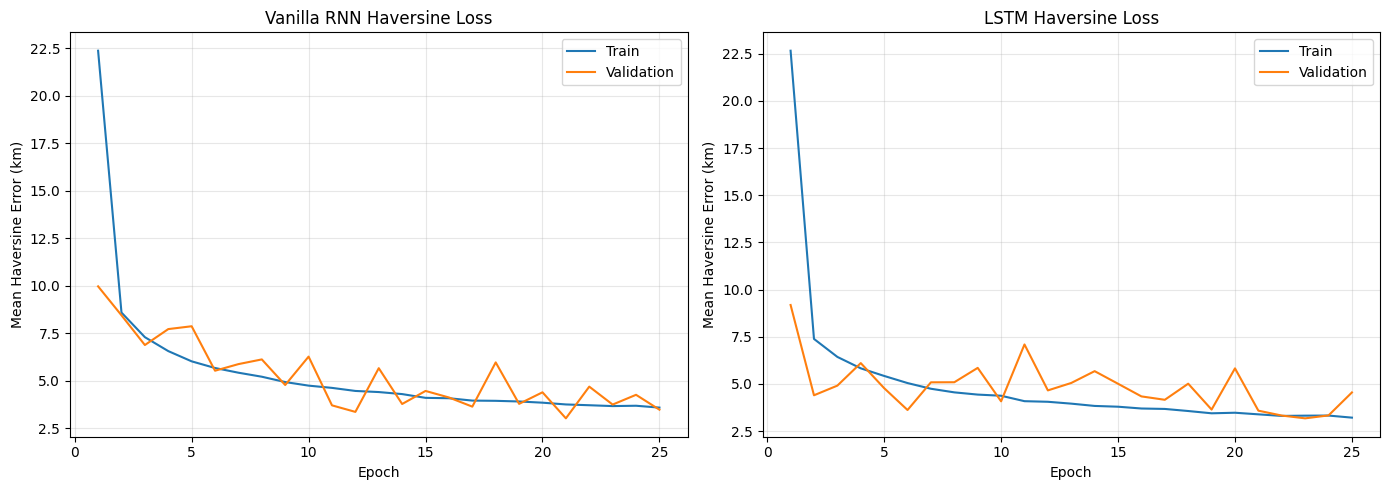

     split    model  mean_haversine_km  median_haversine_km
Validation Baseline           0.179348             0.003455
Validation      RNN           3.484063             2.804367
Validation     LSTM           4.550689             4.010920
      Test Baseline           0.146579             0.003393
      Test      RNN           3.220687             2.517441
      Test     LSTM           4.042323             3.026247


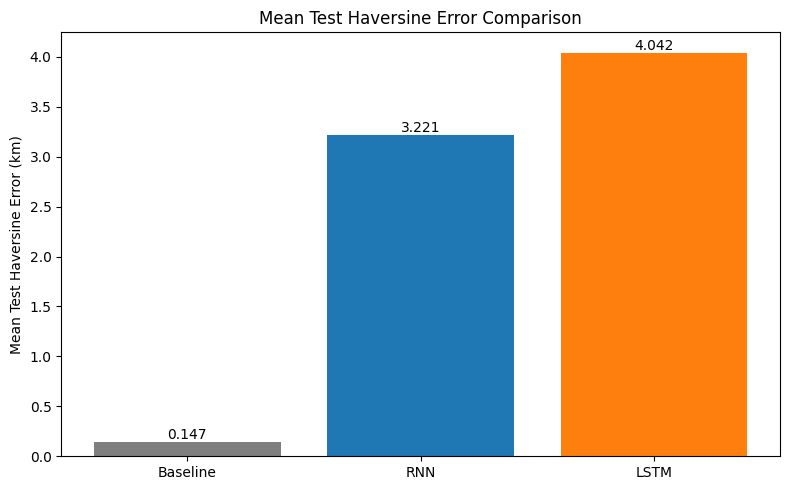

Global threshold: 9.685520 km
Percent anomalies using global threshold: 5.36%
Percent anomalies using per-region threshold: 7.01%
Percent anomalies using per-ship threshold: 5.36%
 true_lat    true_lon  pred_lat    pred_lon   error_km  mmsi_id  region_id  sample_index  global_threshold_km  region_threshold_km  ship_threshold_km  anomaly_global  anomaly_region  anomaly_ship
23.446699  -95.928268 22.518932  -96.022583 103.613902      205         24          1739              9.68552             9.685520            9.68552            True            True          True
32.957020 -118.504531 32.840676 -117.656640  80.211332     1932         87         25858              9.68552             9.620014            9.68552            True            True          True
23.442510  -95.930130 22.817762  -96.158873  73.301048      205         23          1738              9.68552            10.007383            9.68552            True            True          True
49.193699 -123.955366 49.438270 -123

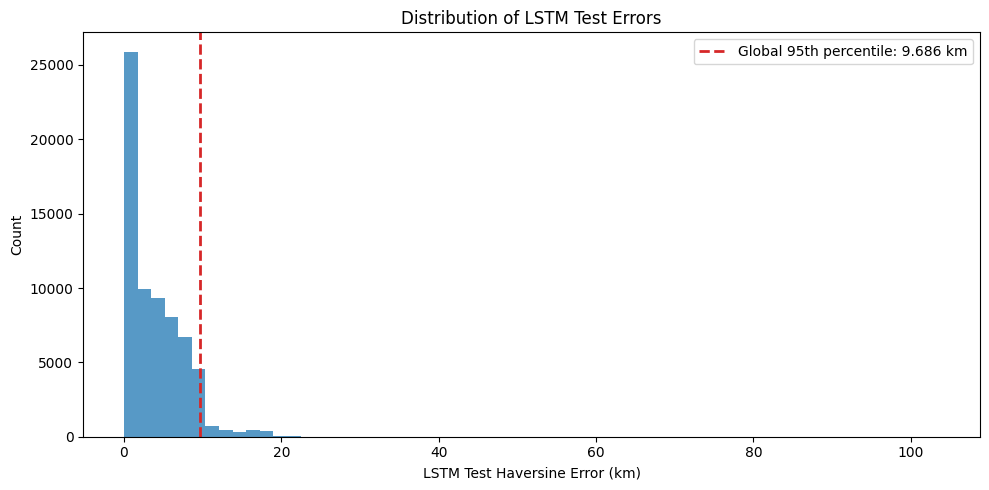

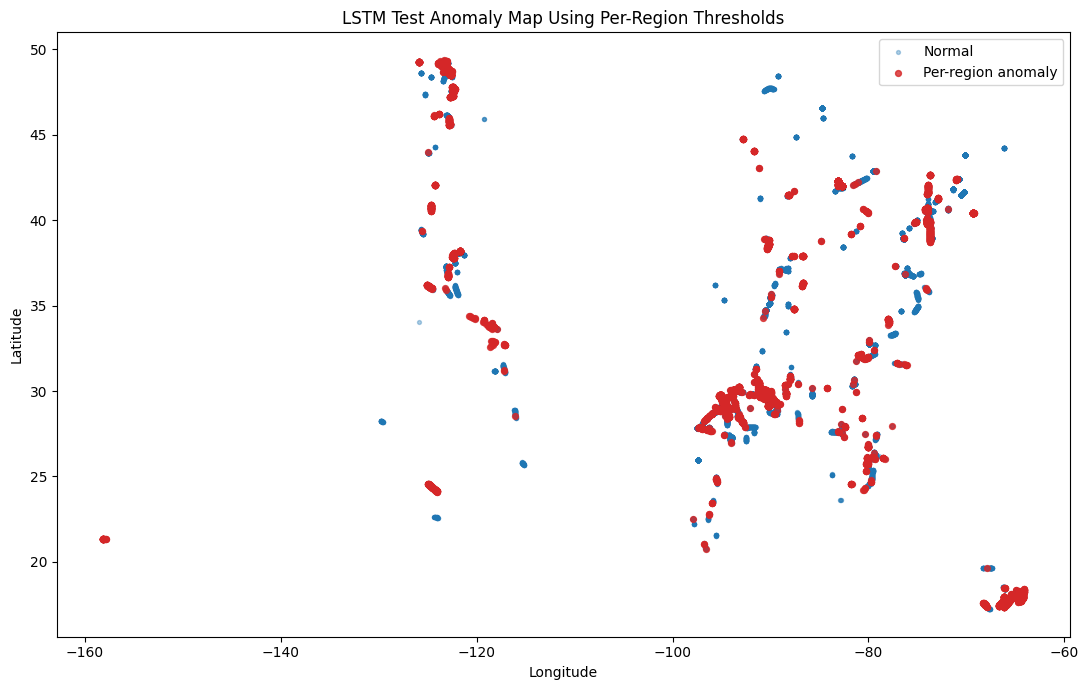

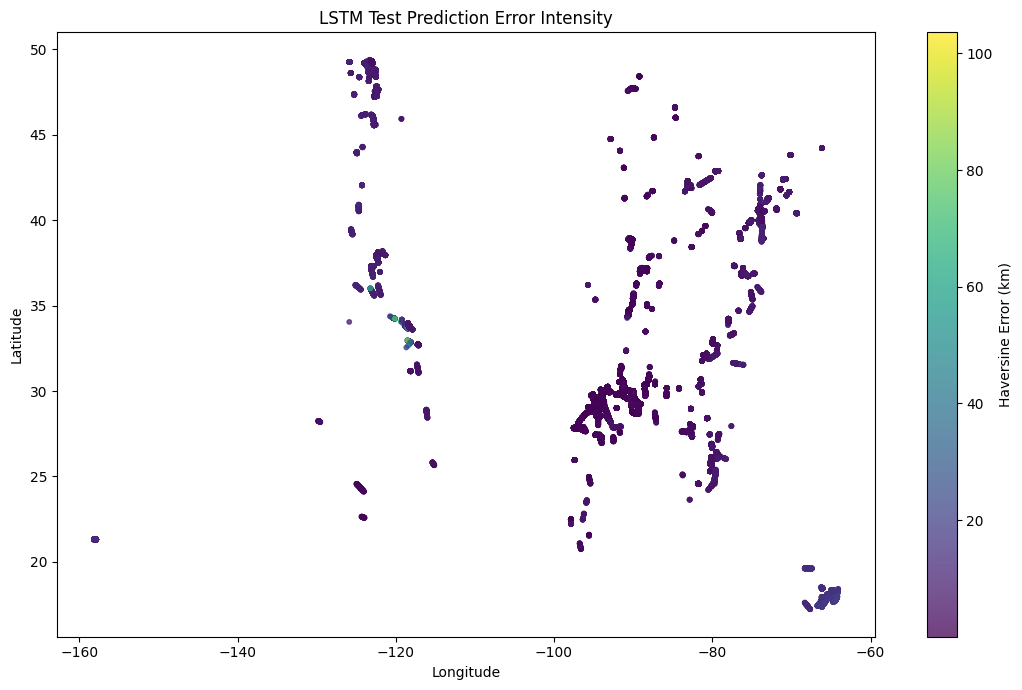

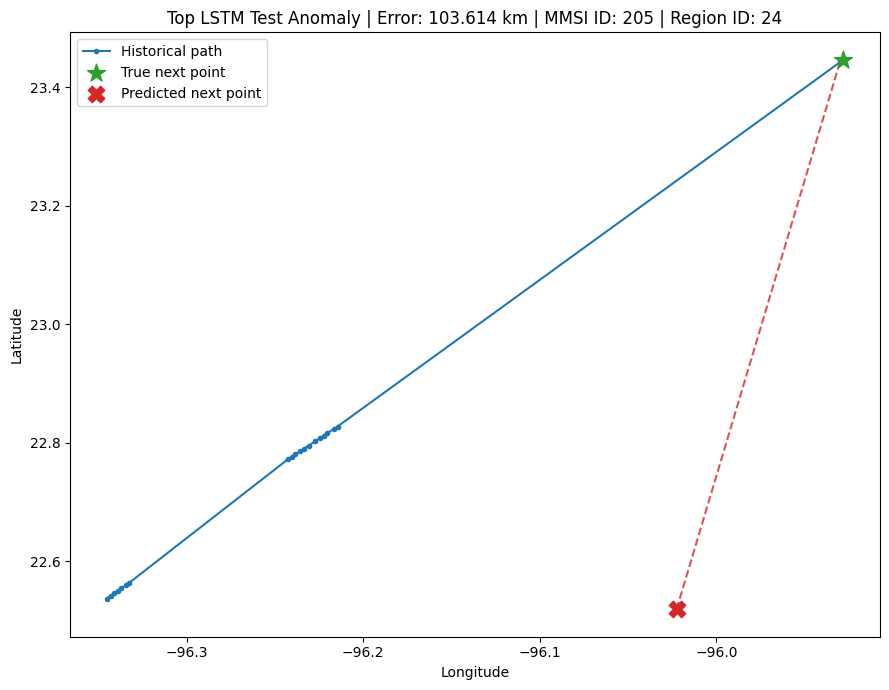

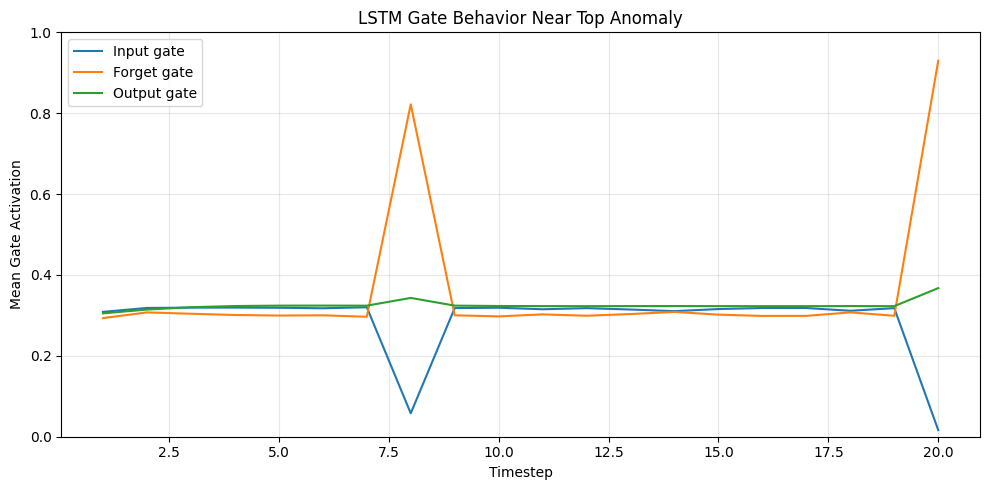

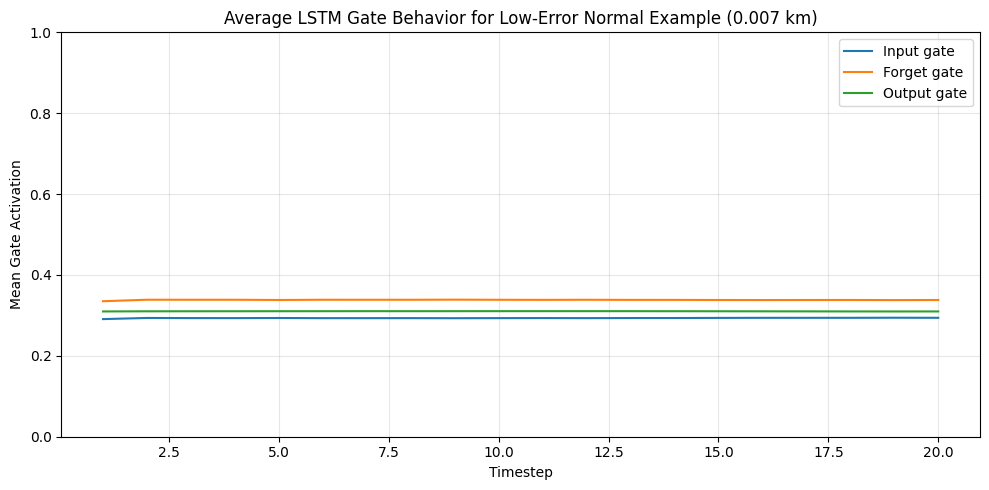

In [4]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

epochs_rnn = np.arange(1, len(rnn_history["train_km"]) + 1)
epochs_lstm = np.arange(1, len(lstm_history["train_km"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_rnn, rnn_history["train_km"], label="Train")
axes[0].plot(epochs_rnn, rnn_history["val_km"], label="Validation")
axes[0].set_title("Vanilla RNN Haversine Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean Haversine Error (km)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_lstm, lstm_history["train_km"], label="Train")
axes[1].plot(epochs_lstm, lstm_history["val_km"], label="Validation")
axes[1].set_title("LSTM Haversine Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean Haversine Error (km)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


def inverse_target_transform(y_scaled):
    values = np.asarray(y_scaled, dtype=np.float64)
    original_shape = values.shape
    values = values.reshape(-1, 2)
    transformed = target_scaler.inverse_transform(values)
    return transformed.reshape(original_shape)


def numpy_haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=np.float64))
    lon1 = np.radians(np.asarray(lon1, dtype=np.float64))
    lat2 = np.radians(np.asarray(lat2, dtype=np.float64))
    lon2 = np.radians(np.asarray(lon2, dtype=np.float64))

    delta_lat = lat2 - lat1
    delta_lon = lon2 - lon1

    a = (
        np.sin(delta_lat / 2.0) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(delta_lon / 2.0) ** 2
    )
    a = np.clip(a, 0.0, 1.0)

    return 6371.0088 * 2.0 * np.arctan2(
        np.sqrt(a),
        np.sqrt(1.0 - a),
    )


@torch.no_grad()
def collect_model_predictions(model, loader, device):
    model.eval()
    frames = []
    sample_offset = 0

    for batch in loader:
        x_scaled = batch["x_scaled"].to(device)
        y_scaled = batch["y_scaled"].to(device)

        output = model(x_scaled)
        if isinstance(output, tuple):
            output = output[0]

        pred_scaled = output.detach().cpu().numpy()
        true_scaled = y_scaled.detach().cpu().numpy()

        pred_original = inverse_target_transform(pred_scaled)
        true_original = inverse_target_transform(true_scaled)

        errors = numpy_haversine_km(
            true_original[:, 0],
            true_original[:, 1],
            pred_original[:, 0],
            pred_original[:, 1],
        )

        batch_size = len(pred_original)
        frames.append(
            pd.DataFrame(
                {
                    "true_lat": true_original[:, 0],
                    "true_lon": true_original[:, 1],
                    "pred_lat": pred_original[:, 0],
                    "pred_lon": pred_original[:, 1],
                    "error_km": errors,
                    "mmsi_id": batch["mmsi_id"].cpu().numpy(),
                    "region_id": batch["region_id"].cpu().numpy(),
                    "sample_index": np.arange(
                        sample_offset,
                        sample_offset + batch_size,
                    ),
                }
            )
        )
        sample_offset += batch_size

    return pd.concat(frames, ignore_index=True)


@torch.no_grad()
def collect_baseline_predictions(loader):
    frames = []
    sample_offset = 0

    for batch in loader:
        x_original = batch["x_original"].cpu().numpy()
        y_original = batch["y_original"].cpu().numpy()

        pred_original = x_original[:, -1, :2]
        true_original = y_original[:, :2]

        errors = numpy_haversine_km(
            true_original[:, 0],
            true_original[:, 1],
            pred_original[:, 0],
            pred_original[:, 1],
        )

        batch_size = len(pred_original)
        frames.append(
            pd.DataFrame(
                {
                    "true_lat": true_original[:, 0],
                    "true_lon": true_original[:, 1],
                    "pred_lat": pred_original[:, 0],
                    "pred_lon": pred_original[:, 1],
                    "error_km": errors,
                    "mmsi_id": batch["mmsi_id"].cpu().numpy(),
                    "region_id": batch["region_id"].cpu().numpy(),
                    "sample_index": np.arange(
                        sample_offset,
                        sample_offset + batch_size,
                    ),
                }
            )
        )
        sample_offset += batch_size

    return pd.concat(frames, ignore_index=True)


val_baseline_df = collect_baseline_predictions(val_loader)
val_rnn_df = collect_model_predictions(rnn_model, val_loader, device)
val_lstm_df = collect_model_predictions(lstm_model, val_loader, device)

test_baseline_df = collect_baseline_predictions(test_loader)
test_rnn_df = collect_model_predictions(rnn_model, test_loader, device)
test_lstm_df = collect_model_predictions(lstm_model, test_loader, device)

comparison_rows = []
for split_name, prediction_frames in {
    "Validation": {
        "Baseline": val_baseline_df,
        "RNN": val_rnn_df,
        "LSTM": val_lstm_df,
    },
    "Test": {
        "Baseline": test_baseline_df,
        "RNN": test_rnn_df,
        "LSTM": test_lstm_df,
    },
}.items():
    for model_name, prediction_df in prediction_frames.items():
        comparison_rows.append(
            {
                "split": split_name,
                "model": model_name,
                "mean_haversine_km": prediction_df["error_km"].mean(),
                "median_haversine_km": prediction_df["error_km"].median(),
            }
        )

comparison_table = pd.DataFrame(comparison_rows)
print(comparison_table.to_string(index=False))

test_means = [
    test_baseline_df["error_km"].mean(),
    test_rnn_df["error_km"].mean(),
    test_lstm_df["error_km"].mean(),
]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    ["Baseline", "RNN", "LSTM"],
    test_means,
    color=["tab:gray", "tab:blue", "tab:orange"],
)
plt.ylabel("Mean Test Haversine Error (km)")
plt.title("Mean Test Haversine Error Comparison")
plt.bar_label(bars, fmt="%.3f")
plt.tight_layout()
plt.show()

global_threshold = np.percentile(val_lstm_df["error_km"], 95)

region_statistics = (
    val_lstm_df.groupby("region_id")["error_km"]
    .agg(
        sample_count="size",
        threshold_95=lambda values: np.percentile(values, 95),
    )
)
region_statistics["threshold"] = np.where(
    region_statistics["sample_count"] >= 20,
    region_statistics["threshold_95"],
    global_threshold,
)
region_thresholds = region_statistics["threshold"].to_dict()

ship_statistics = (
    val_lstm_df.groupby("mmsi_id")["error_km"]
    .agg(
        sample_count="size",
        threshold_95=lambda values: np.percentile(values, 95),
    )
)
ship_statistics["threshold"] = np.where(
    ship_statistics["sample_count"] >= 20,
    ship_statistics["threshold_95"],
    global_threshold,
)
ship_thresholds = ship_statistics["threshold"].to_dict()

test_lstm_df["global_threshold_km"] = global_threshold
test_lstm_df["region_threshold_km"] = (
    test_lstm_df["region_id"].map(region_thresholds).fillna(global_threshold)
)
test_lstm_df["ship_threshold_km"] = (
    test_lstm_df["mmsi_id"].map(ship_thresholds).fillna(global_threshold)
)

test_lstm_df["anomaly_global"] = (
    test_lstm_df["error_km"] > test_lstm_df["global_threshold_km"]
)
test_lstm_df["anomaly_region"] = (
    test_lstm_df["error_km"] > test_lstm_df["region_threshold_km"]
)
test_lstm_df["anomaly_ship"] = (
    test_lstm_df["error_km"] > test_lstm_df["ship_threshold_km"]
)

print(f"Global threshold: {global_threshold:.6f} km")
print(
    "Percent anomalies using global threshold: "
    f"{100.0 * test_lstm_df['anomaly_global'].mean():.2f}%"
)
print(
    "Percent anomalies using per-region threshold: "
    f"{100.0 * test_lstm_df['anomaly_region'].mean():.2f}%"
)
print(
    "Percent anomalies using per-ship threshold: "
    f"{100.0 * test_lstm_df['anomaly_ship'].mean():.2f}%"
)

top_10_test_examples = test_lstm_df.nlargest(10, "error_km")
print(top_10_test_examples.to_string(index=False))

plt.figure(figsize=(10, 5))
plt.hist(
    test_lstm_df["error_km"],
    bins=60,
    color="tab:blue",
    alpha=0.75,
)
plt.axvline(
    global_threshold,
    color="tab:red",
    linestyle="--",
    linewidth=2,
    label=f"Global 95th percentile: {global_threshold:.3f} km",
)
plt.xlabel("LSTM Test Haversine Error (km)")
plt.ylabel("Count")
plt.title("Distribution of LSTM Test Errors")
plt.legend()
plt.tight_layout()
plt.show()

normal_mask = ~test_lstm_df["anomaly_region"]
anomaly_mask = test_lstm_df["anomaly_region"]

plt.figure(figsize=(11, 7))
plt.scatter(
    test_lstm_df.loc[normal_mask, "true_lon"],
    test_lstm_df.loc[normal_mask, "true_lat"],
    s=8,
    alpha=0.35,
    color="tab:blue",
    label="Normal",
)
plt.scatter(
    test_lstm_df.loc[anomaly_mask, "true_lon"],
    test_lstm_df.loc[anomaly_mask, "true_lat"],
    s=18,
    alpha=0.8,
    color="tab:red",
    label="Per-region anomaly",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("LSTM Test Anomaly Map Using Per-Region Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 7))
error_scatter = plt.scatter(
    test_lstm_df["true_lon"],
    test_lstm_df["true_lat"],
    c=test_lstm_df["error_km"],
    cmap="viridis",
    s=10,
    alpha=0.75,
)
plt.colorbar(error_scatter, label="Haversine Error (km)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("LSTM Test Prediction Error Intensity")
plt.tight_layout()
plt.show()

top_anomaly = test_lstm_df.nlargest(1, "error_km").iloc[0]
top_sample_index = int(top_anomaly["sample_index"])
top_sample = test_loader.dataset[top_sample_index]

top_path = top_sample["x_original"].detach().cpu().numpy()
top_true = np.array(
    [top_anomaly["true_lat"], top_anomaly["true_lon"]]
)
top_prediction = np.array(
    [top_anomaly["pred_lat"], top_anomaly["pred_lon"]]
)

plt.figure(figsize=(9, 7))
plt.plot(
    top_path[:, 1],
    top_path[:, 0],
    color="tab:blue",
    marker="o",
    markersize=3,
    linewidth=1.5,
    label="Historical path",
)
plt.scatter(
    top_true[1],
    top_true[0],
    color="tab:green",
    marker="*",
    s=180,
    label="True next point",
    zorder=5,
)
plt.scatter(
    top_prediction[1],
    top_prediction[0],
    color="tab:red",
    marker="X",
    s=140,
    label="Predicted next point",
    zorder=5,
)
plt.plot(
    [top_path[-1, 1], top_true[1]],
    [top_path[-1, 0], top_true[0]],
    color="tab:green",
    linestyle="--",
    alpha=0.8,
)
plt.plot(
    [top_path[-1, 1], top_prediction[1]],
    [top_path[-1, 0], top_prediction[0]],
    color="tab:red",
    linestyle="--",
    alpha=0.8,
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(
    f"Top LSTM Test Anomaly | Error: {top_anomaly['error_km']:.3f} km | "
    f"MMSI ID: {int(top_anomaly['mmsi_id'])} | "
    f"Region ID: {int(top_anomaly['region_id'])}"
)
plt.legend()
plt.tight_layout()
plt.show()


@torch.no_grad()
def extract_gate_means(model, dataset, sample_index, device):
    model.eval()
    sample = dataset[int(sample_index)]
    x_scaled = sample["x_scaled"].unsqueeze(0).to(device)

    _, gates = model(x_scaled, return_gates=True)

    return {
        "input": gates["input_gates"].mean(dim=2).squeeze(0).cpu().numpy(),
        "forget": gates["forget_gates"].mean(dim=2).squeeze(0).cpu().numpy(),
        "output": gates["output_gates"].mean(dim=2).squeeze(0).cpu().numpy(),
    }


top_gate_means = extract_gate_means(
    lstm_model,
    test_loader.dataset,
    top_sample_index,
    device,
)
top_timesteps = np.arange(1, len(top_gate_means["input"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(top_timesteps, top_gate_means["input"], label="Input gate")
plt.plot(top_timesteps, top_gate_means["forget"], label="Forget gate")
plt.plot(top_timesteps, top_gate_means["output"], label="Output gate")
plt.xlabel("Timestep")
plt.ylabel("Mean Gate Activation")
plt.title("LSTM Gate Behavior Near Top Anomaly")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

low_error_normal = (
    test_lstm_df.loc[~test_lstm_df["anomaly_global"]]
    .nsmallest(1, "error_km")
    .iloc[0]
)
normal_sample_index = int(low_error_normal["sample_index"])

normal_gate_means = extract_gate_means(
    lstm_model,
    test_loader.dataset,
    normal_sample_index,
    device,
)
normal_timesteps = np.arange(1, len(normal_gate_means["input"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(normal_timesteps, normal_gate_means["input"], label="Input gate")
plt.plot(normal_timesteps, normal_gate_means["forget"], label="Forget gate")
plt.plot(normal_timesteps, normal_gate_means["output"], label="Output gate")
plt.xlabel("Timestep")
plt.ylabel("Mean Gate Activation")
plt.title(
    f"Average LSTM Gate Behavior for Low-Error Normal Example "
    f"({low_error_normal['error_km']:.3f} km)"
)
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()